In [1]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('df_est_sel.csv')


In [20]:
df['Data_hora'] = pd.to_datetime(df['Data_hora'])
df['Data'] = df['Data_hora'].dt.date
df['Hora'] = df['Data_hora'].dt.hour

In [21]:
media_horaria = (
    df.groupby(["Estado","Estacao", "Poluente", "Data", "Hora"])["Valor"]
    .mean()
    .reset_index(name="media_horaria")
)

contagem_horas_validas = (
    media_horaria.groupby(["Estado","Estacao", "Poluente", "Data"])
    .agg(
        media_diaria=('media_horaria', 'mean'), 
        horas_validas=('media_horaria', 'count') 
    )
    .reset_index()
)

contagem_horas_validas["dia_valido"] = contagem_horas_validas["horas_validas"] >= 16

In [22]:
df = contagem_horas_validas[contagem_horas_validas["dia_valido"] == True]

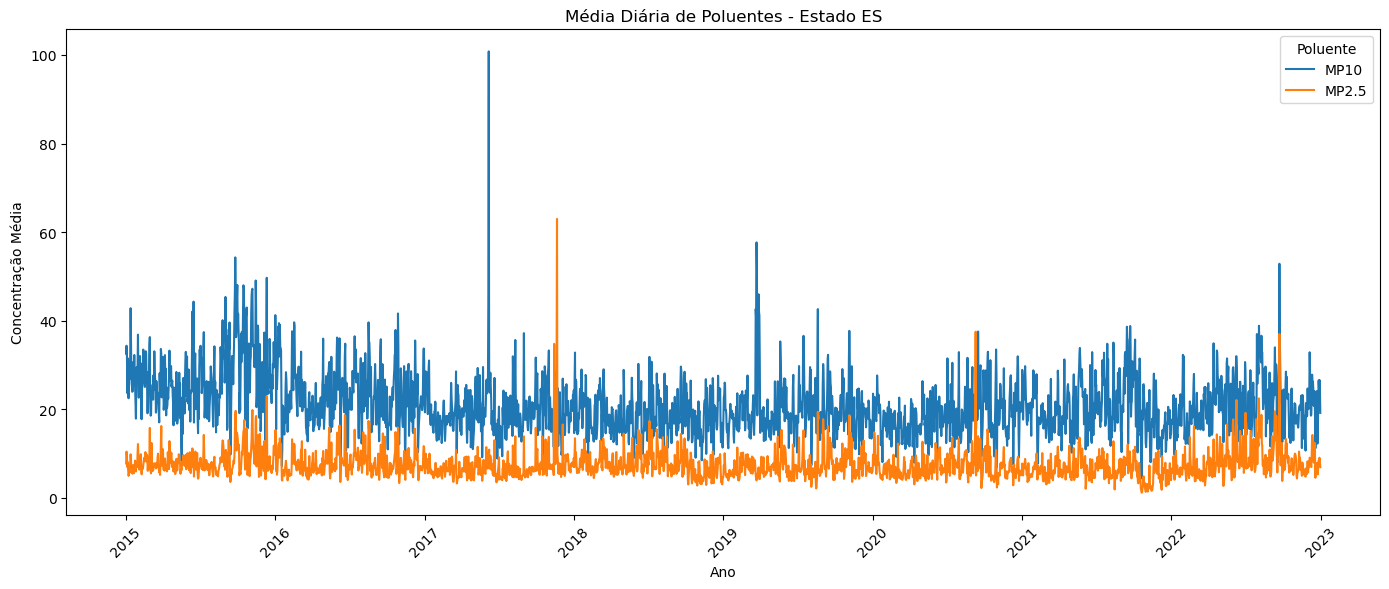

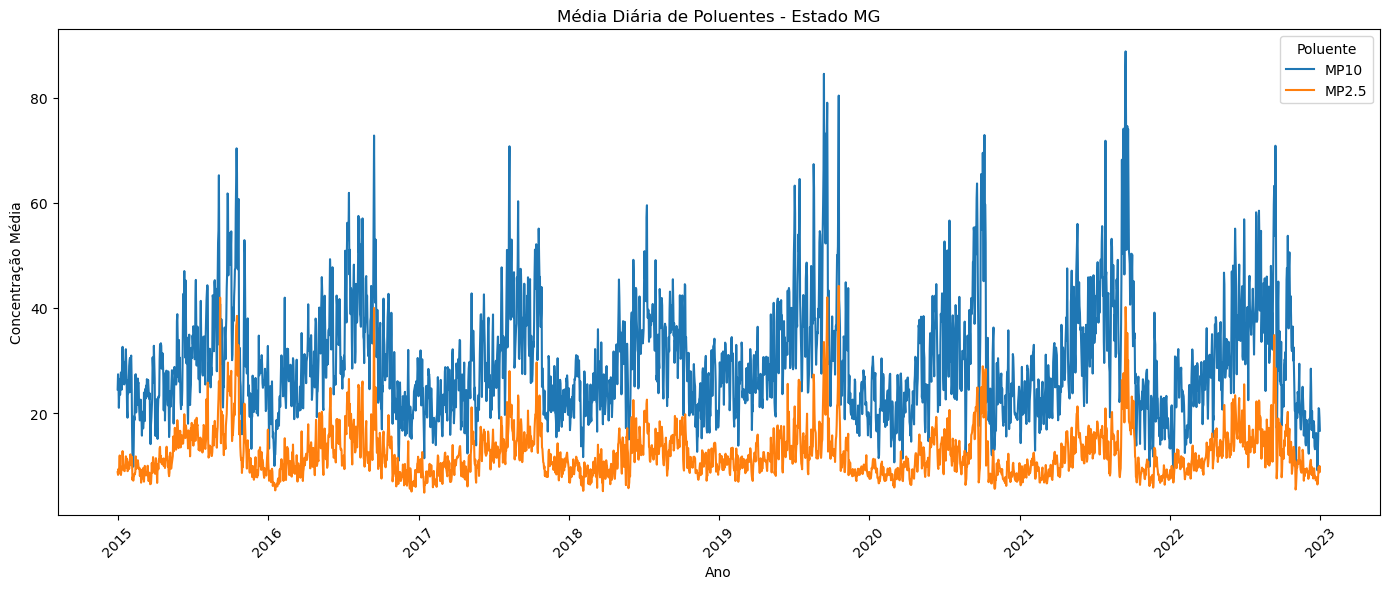

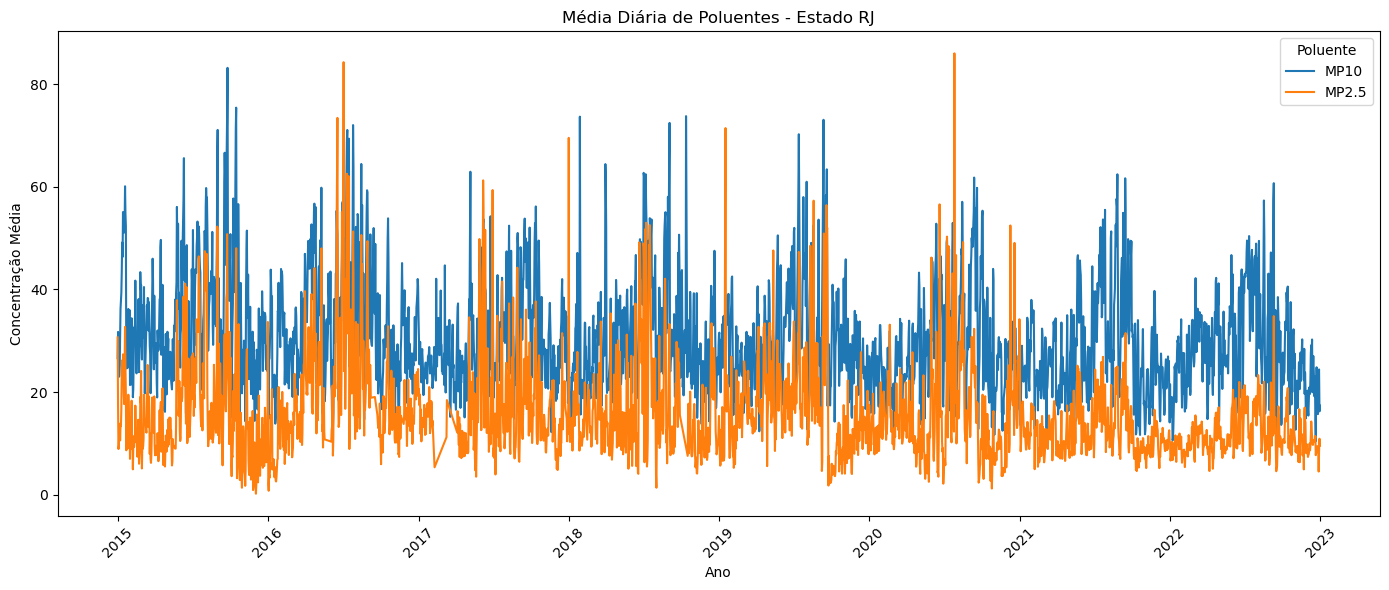

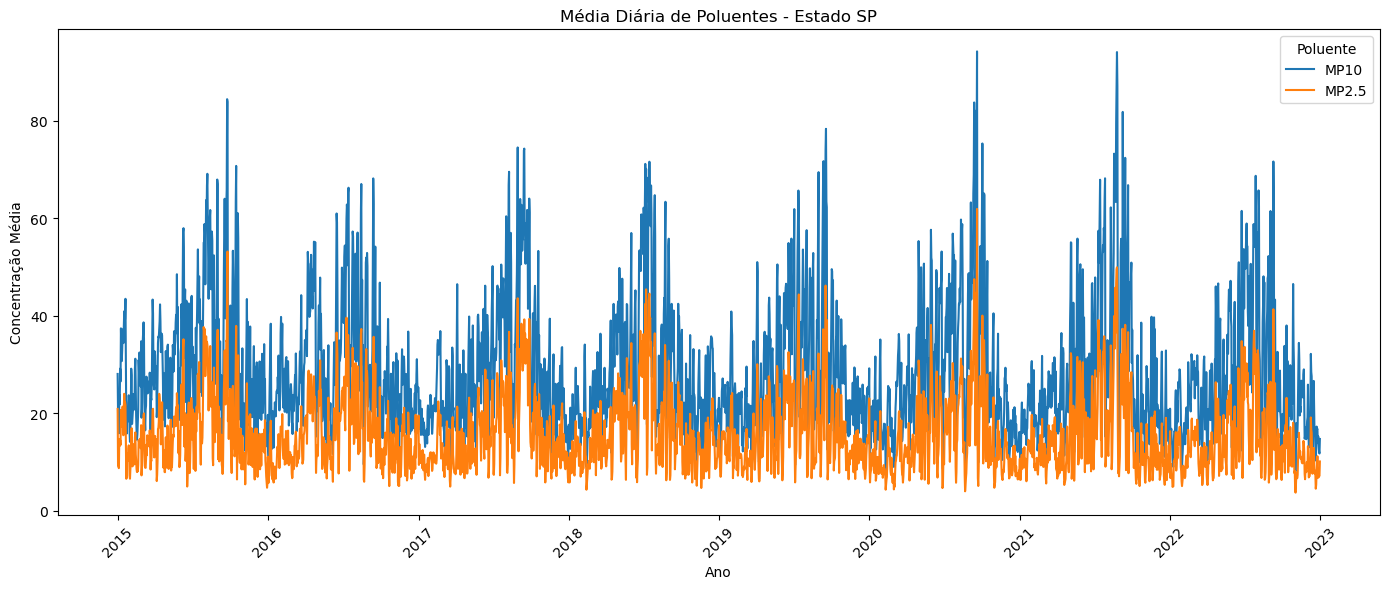

In [43]:
for estado in df['Estado'].unique():
    # Filtrar estado
    df_estado = df[df['Estado'] == estado]

    #df_estado = df_estado[df_estado['Data'] > datetime.date(2015, 1, 1)] # filtro de data para melhorar a visualização

    # Agrupar por data e poluente
    df_estado = df_estado.groupby(['Data', 'Poluente'], as_index=False)['media_diaria'].mean()

    # Plot
    plt.figure(figsize=(14,6))
    sns.lineplot(data=df_estado, x='Data', y='media_diaria', hue='Poluente')

    # Ajustes visuais
    plt.title(f'Média Diária de Poluentes - Estado {estado}')
    plt.xlabel('Ano')
    plt.ylabel('Concentração Média')
    plt.legend(title='Poluente')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()